# MOBIS SpeedTransformer – train-class failure analysis

Analyze the existing run `mobis_lr1e-4_bs512_h8_d128_kv4_do0.1` without retraining: rebuild the MOBIS splits, evaluate the saved model on windows whose true label is **train**, and cluster misclassifications into two failure profiles with supporting visuals.

In [1]:
# Minimal dependency helper (keeps torch manual to avoid pulling the wrong CUDA build)
AUTO_INSTALL = True  # set False if you prefer to manage packages yourself

import importlib, subprocess, sys
packages = {
    "pandas": "pandas",
    "numpy": "numpy",
    "tqdm": "tqdm",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
    "joblib": "joblib",
}
for import_name, pip_name in packages.items():
    try:
        importlib.import_module(import_name if import_name != "sklearn" else "sklearn")
    except ImportError:
        if not AUTO_INSTALL:
            raise
        print(f"Installing {pip_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])

try:
    import torch  # noqa: F401
except ImportError as exc:
    raise SystemExit("Install torch (GPU build) before running this notebook.") from exc


In [2]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix

import torch
from torch.utils.data import Dataset, DataLoader

sns.set_context("talk")

RUN_DIR = Path("/data/A-SpeedTransformer/models/transformer/experiments/mobis_transformer_sweeps/mobis_lr1e-4_bs512_h8_d128_kv4_do0.1")
DATA_PATH = Path("/data/A-SpeedTransformer/data/mobis_processed.csv")
TRANSFORMER_DIR = Path("/data/A-SpeedTransformer/models/transformer")
FEATURE_COLUMNS = ["speed"]
TARGET_LABEL = "train"
WINDOW_SIZE = 200
STRIDE = 50
BATCH_SIZE = 512
CHUNKSIZE = 500_000
SEED = 316

if str(TRANSFORMER_DIR) not in sys.path:
    sys.path.append(str(TRANSFORMER_DIR))
from model_utils import TrajectoryModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [3]:
# Load saved artifacts and model
label_encoder = joblib.load(RUN_DIR / "label_encoder.joblib")
scaler = joblib.load(RUN_DIR / "scaler.joblib")

model = TrajectoryModel(feature_columns=FEATURE_COLUMNS, label_encoder=label_encoder, device=device, use_amp=False)
model.prepare_model(
    window_size=WINDOW_SIZE,
    d_model=128,
    nhead=8,
    num_layers=4,
    dropout=0.1,
    kv_heads=4,
)
state = torch.load(RUN_DIR / "best_model.pth", map_location=device)
model.model.load_state_dict(state)
model.model.eval(); torch.set_grad_enabled(False)

class_names = list(label_encoder.classes_)
target_class_id = int(label_encoder.transform([TARGET_LABEL])[0])
print(f"Loaded model for classes: {class_names}")
print(f"Running on device: {device}")


Loaded model for classes: ['bike', 'bus', 'car', 'train', 'walk']
Running on device: cuda


/tmp/ipykernel_296326/3007840747.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(RUN_DIR / "best_model.pth", map_location=device)


In [4]:
# Deterministic split that mirrors training

def compute_splits(data_path, traj_id_column="traj_id", test_size=0.15, val_size=0.15, seed=SEED, chunksize=CHUNKSIZE):
    unique_ids = set()
    for chunk in tqdm(pd.read_csv(data_path, usecols=[traj_id_column], chunksize=chunksize), desc="collect traj_ids"):
        unique_ids.update(chunk[traj_id_column].unique())
    traj_ids = sorted(unique_ids)
    train_ids, temp_ids = train_test_split(traj_ids, test_size=(val_size + test_size), random_state=seed, shuffle=True)
    val_ratio = val_size / (val_size + test_size)
    val_ids, test_ids = train_test_split(temp_ids, test_size=(1 - val_ratio), random_state=seed, shuffle=True)
    return set(train_ids), set(val_ids), set(test_ids)

train_ids, val_ids, test_ids = compute_splits(DATA_PATH)
print(f"traj_ids -> train {len(train_ids)} | val {len(val_ids)} | test {len(test_ids)}")


collect traj_ids: 290it [02:56,  1.64it/s]


traj_ids -> train 1071673 | val 229644 | test 229645


In [5]:
# Sliding-window helpers (match training)

def sliding_windows(seq: np.ndarray, window_size: int = WINDOW_SIZE, stride: int = STRIDE):
    windows, masks = [], []
    seq_len = seq.shape[0]
    for start in range(0, seq_len, stride):
        end = start + window_size
        window = seq[start:end]
        actual_len = window.shape[0]
        mask = np.zeros(window_size, dtype=bool)
        if actual_len < window_size:
            padded = np.zeros((window_size, window.shape[1]), dtype=window.dtype)
            padded[:actual_len] = window
            window = padded
            mask[actual_len:] = True
            windows.append(window)
            masks.append(mask)
            break
        windows.append(window)
        masks.append(mask)
        if end >= seq_len:
            break
    return windows, masks


def build_windows_for_label(data_path, target_label, test_ids, scaler, feature_columns, chunksize=CHUNKSIZE):
    target_id = int(label_encoder.transform([target_label])[0])
    sequences, masks, labels, trajs, win_pos = [], [], [], [], []
    for chunk in tqdm(pd.read_csv(data_path, chunksize=chunksize), desc=f"chunking {target_label}"):
        chunk = chunk[chunk["traj_id"].isin(test_ids) & (chunk["label"] == target_label)]
        if chunk.empty:
            continue
        grouped = chunk.groupby("traj_id")
        for tid, group in grouped:
            feats = scaler.transform(group[feature_columns])
            w, m = sliding_windows(feats)
            sequences.extend(w)
            masks.extend(m)
            labels.extend([target_id] * len(w))
            trajs.extend([tid] * len(w))
            win_pos.extend(list(range(len(w))))
    return sequences, masks, labels, trajs, win_pos

sequences, masks, labels, traj_ids, window_pos = build_windows_for_label(
    DATA_PATH, TARGET_LABEL, test_ids, scaler, FEATURE_COLUMNS
)
print(f"Collected {len(sequences)} windows for label '{TARGET_LABEL}' in test split")


chunking train: 290it [04:55,  1.02s/it]

Collected 23799 windows for label 'train' in test split


In [6]:
# Tensorize and run inference
seq_array = np.stack(sequences).astype(np.float32)
mask_array = np.stack(masks).astype(bool)
label_array = np.array(labels, dtype=np.int64)
traj_array = np.array(traj_ids)
winpos_array = np.array(window_pos)

class SeqDataset(Dataset):
    def __init__(self, seqs, masks, labels):
        self.seqs = seqs
        self.masks = masks
        self.labels = labels
    def __len__(self):
        return len(self.seqs)
    def __getitem__(self, idx):
        return (
            torch.from_numpy(self.seqs[idx]),
            torch.from_numpy(self.masks[idx]),
            torch.tensor(self.labels[idx], dtype=torch.long),
        )

dataset = SeqDataset(seq_array, mask_array, label_array)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

preds = np.empty(len(dataset), dtype=np.int64)
max_probs = np.empty(len(dataset), dtype=np.float32)
true_probs = np.empty(len(dataset), dtype=np.float32)

cursor = 0
with torch.no_grad():
    for batch_seqs, batch_masks, batch_labels in tqdm(loader, desc="inference"):
        batch_seqs = batch_seqs.to(device)
        batch_masks = batch_masks.to(device)
        batch_labels = batch_labels.to(device)

        logits = model.model(batch_seqs, None, src_key_padding_mask=batch_masks)
        probs = torch.softmax(logits, dim=1)
        top_prob, pred = probs.max(dim=1)

        bs = batch_seqs.size(0)
        preds[cursor:cursor+bs] = pred.cpu().numpy()
        max_probs[cursor:cursor+bs] = top_prob.cpu().numpy()
        true_probs[cursor:cursor+bs] = probs[torch.arange(bs), batch_labels].cpu().numpy()
        cursor += bs

print(f"Predictions complete. Misclassifications: {(preds != label_array).sum()} / {len(preds)}")


inference: 100%|██████████| 47/47 [00:07<00:00,  6.21it/s]

Predictions complete. Misclassifications: 13804 / 23799


In [7]:
# Build analysis DataFrame

def summarize_speed(seq, mask):
    valid = seq[~mask][:, 0]
    return {
        "length": len(valid),
        "mean_speed": float(valid.mean()),
        "std_speed": float(valid.std(ddof=0)),
        "p90_speed": float(np.percentile(valid, 90)),
        "p10_speed": float(np.percentile(valid, 10)),
        "low_speed_ratio": float(np.mean(valid < 2.0)),
        "high_speed_ratio": float(np.mean(valid > 15.0)),
    }

summary_rows = [summarize_speed(seq_array[i], mask_array[i]) for i in range(len(seq_array))]

df_train = pd.DataFrame(summary_rows)
df_train["traj_id"] = traj_array
df_train["window_idx"] = winpos_array
df_train["true_label"] = label_encoder.inverse_transform(label_array)
df_train["pred_label"] = label_encoder.inverse_transform(preds)
df_train["pred_prob"] = max_probs
df_train["true_prob"] = true_probs
df_train["correct"] = preds == label_array
df_train["failure_profile"] = np.nan

print(df_train.head())
print(df_train.correct.value_counts())


   length  mean_speed  std_speed  p90_speed  p10_speed  low_speed_ratio  \
0      41    0.171717   1.161760   1.636003  -0.585065         0.902439   
1      26    0.678496   2.355508   1.568296  -0.527914         0.884615   
2     156    0.192379   1.103530   1.218133  -0.571975         0.935897   
3     189    0.522327   1.761160   2.958939  -0.613134         0.830688   
4      29    0.719148   1.743781   1.212713  -0.237725         0.965517   

   high_speed_ratio   traj_id  window_idx true_label pred_label  pred_prob  \
0               0.0  11698075           0      train        car   0.809617   
1               0.0  11828949           0      train      train   0.541383   
2               0.0  12235613           0      train        car   0.993718   
3               0.0  12236598           0      train        car   0.979574   
4               0.0  12363576           0      train        car   0.794659   

   true_prob  correct  failure_profile  
0   0.190345    False              NaN 

Train-class window accuracy (test split): 0.420 | misclass rate: 0.580
Where 'train' windows are sent:
car     13553
walk      251
Name: pred_label, dtype: int64


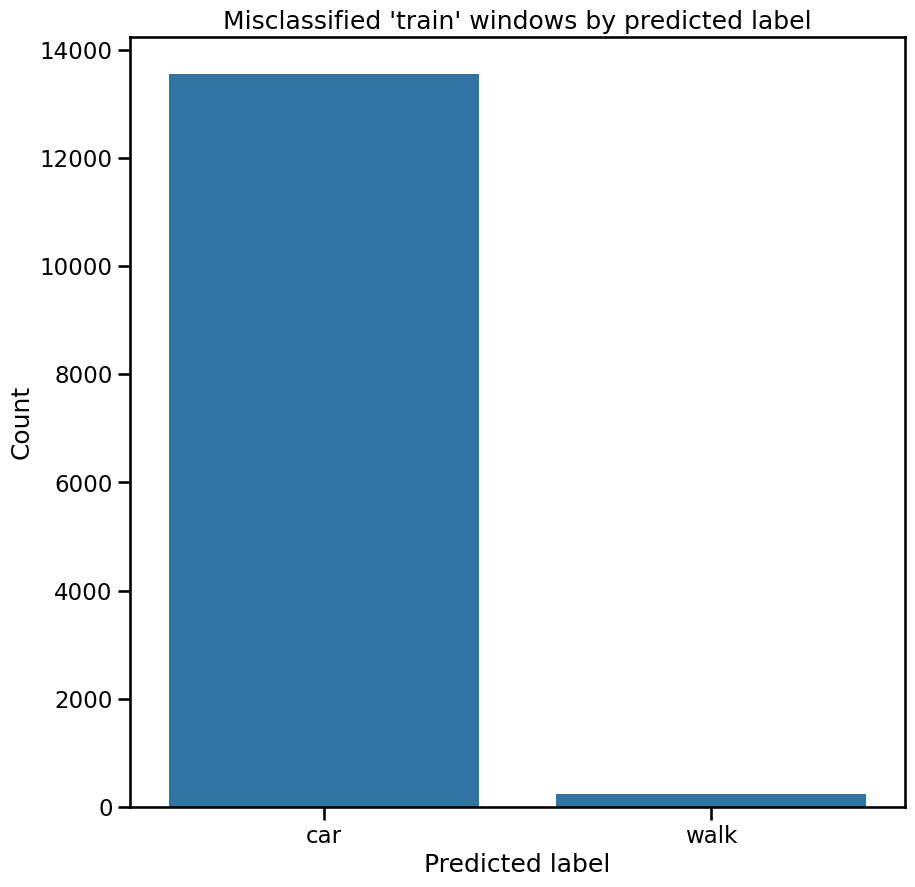

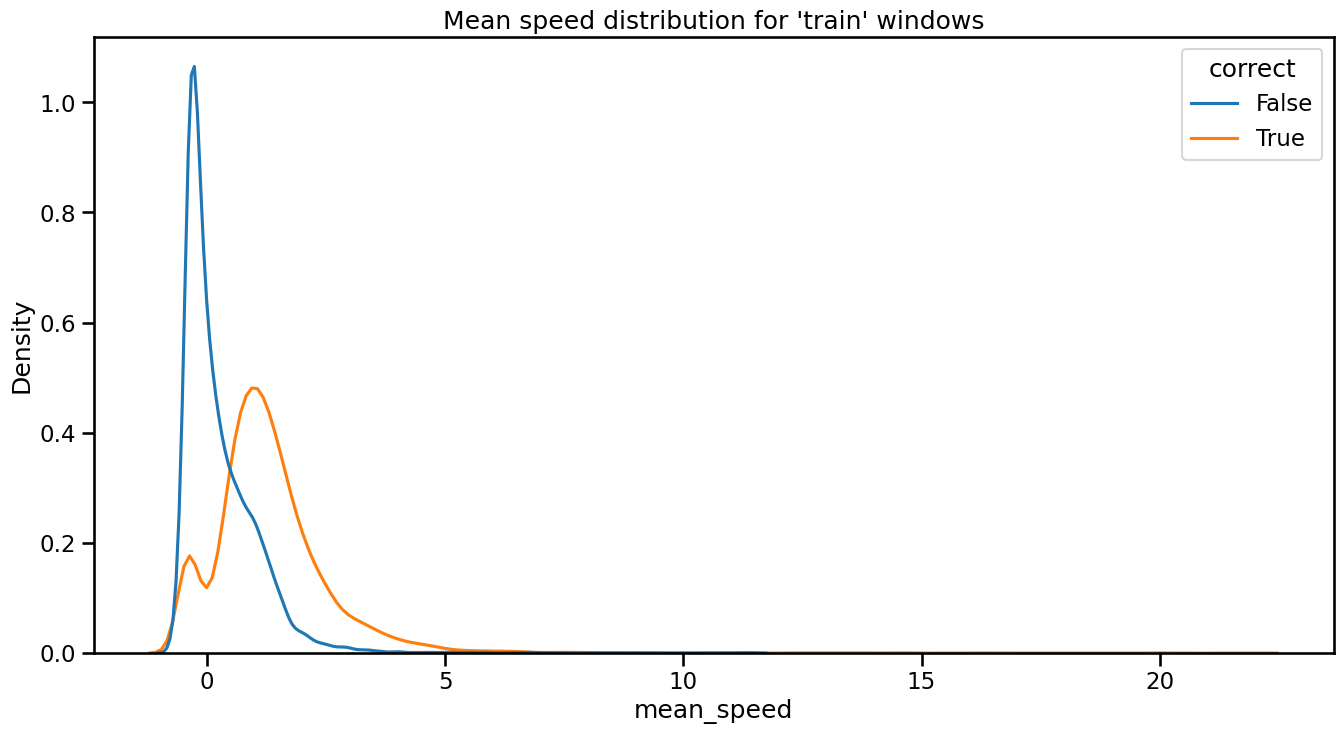

In [14]:
# Quick diagnostics for the train class
acc = df_train.correct.mean()
print(f"Train-class window accuracy (test split): {acc:.3f} | misclass rate: {1-acc:.3f}")

pred_breakdown = df_train[~df_train["correct"]]["pred_label"].value_counts()
print("Where 'train' windows are sent:")
print(pred_breakdown)

fig, ax = plt.subplots(figsize=(10, 10))
(sns.barplot(x=pred_breakdown.index, y=pred_breakdown.values, ax=ax)
    .set(title="Misclassified 'train' windows by predicted label", xlabel="Predicted label", ylabel="Count"))
plt.show()

fig, ax = plt.subplots(figsize=(16, 8))
sns.kdeplot(data=df_train, x="mean_speed", hue="correct", common_norm=False, ax=ax)
ax.set_title("Mean speed distribution for 'train' windows")
plt.show()

In [9]:
# Two failure profiles via clustering on misclassifications
from sklearn.preprocessing import StandardScaler as SkScaler

mis_df = df_train.loc[~df_train["correct"]].copy()
if len(mis_df) < 2:
    print("Not enough misclassifications to cluster.")
else:
    feat_cols = ["mean_speed", "std_speed", "p90_speed", "low_speed_ratio", "high_speed_ratio"]
    X = mis_df[feat_cols].values
    X_scaled = SkScaler().fit_transform(X)
    kmeans = KMeans(n_clusters=2, random_state=SEED, n_init=20)
    mis_df["failure_profile"] = kmeans.fit_predict(X_scaled)
    df_train.loc[mis_df.index, "failure_profile"] = mis_df["failure_profile"]

    size_summary = mis_df.failure_profile.value_counts().rename_axis("failure_profile").reset_index(name="windows")
    display(size_summary)

    profile_summary = mis_df.groupby("failure_profile").agg({
        "traj_id": "nunique",
        "pred_label": lambda s: s.mode().iat[0],
        "pred_prob": "median",
        "mean_speed": "median",
        "std_speed": "median",
        "p90_speed": "median",
        "low_speed_ratio": "median",
        "high_speed_ratio": "median",
    }).rename(columns={"traj_id": "unique_traj_ids"})
    display(profile_summary)


,failure_profile,windows
0,0,11304
1,1,2500


,unique_traj_ids,pred_label,pred_prob,mean_speed,std_speed,p90_speed,low_speed_ratio,high_speed_ratio
failure_profile,,,,,,,,
0,9178,car,0.825476,-0.135025,0.394129,0.313025,1.000000,0.0
1,2321,car,0.683002,1.058403,1.816212,2.911278,0.787879,0.0


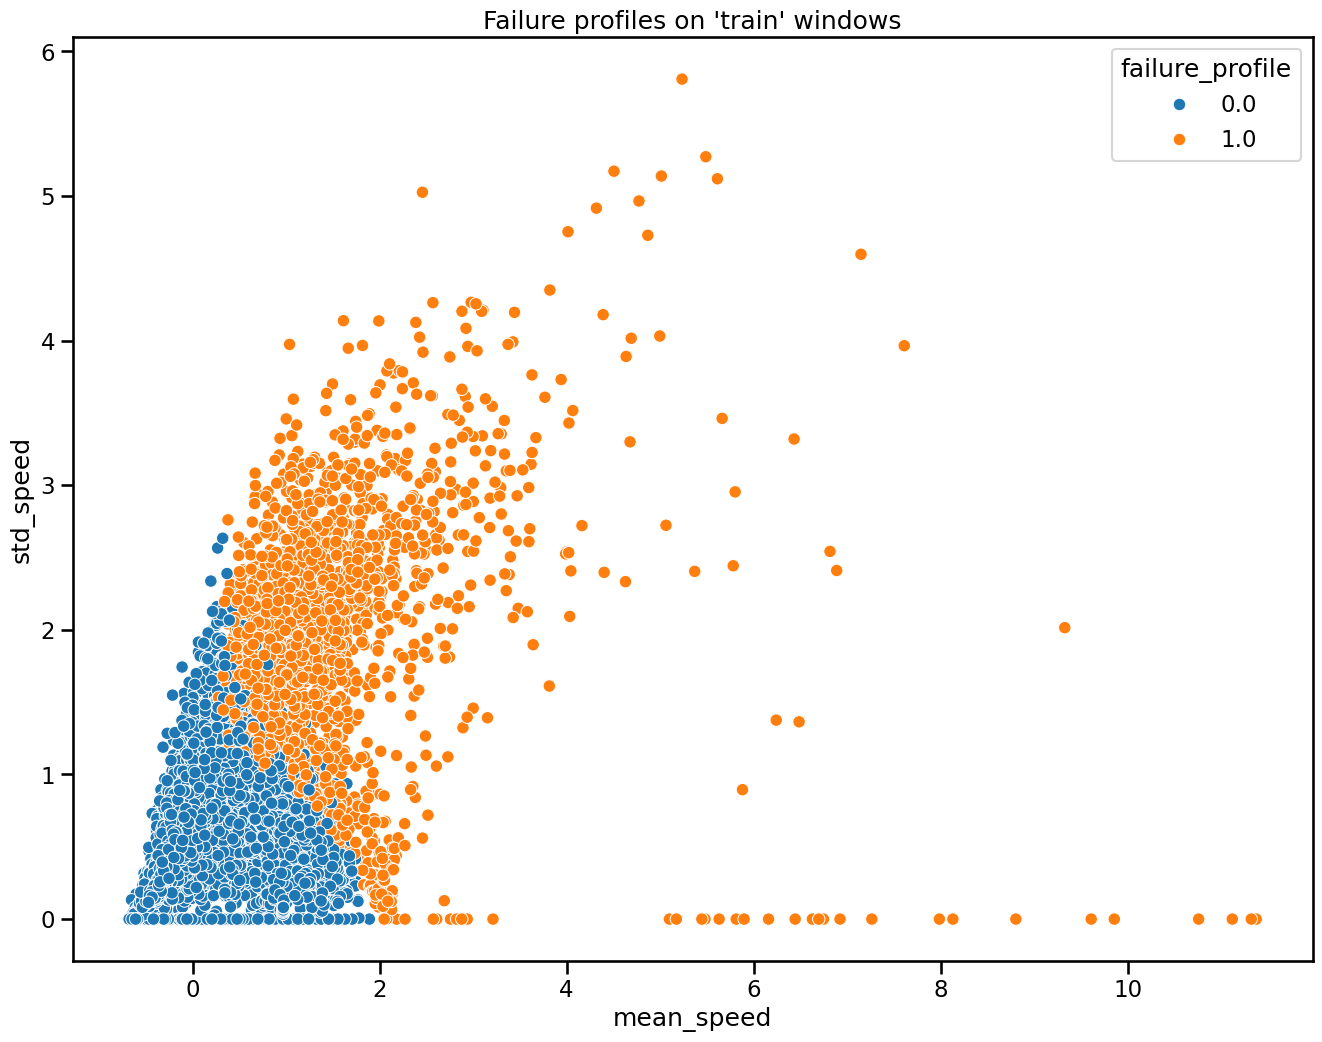

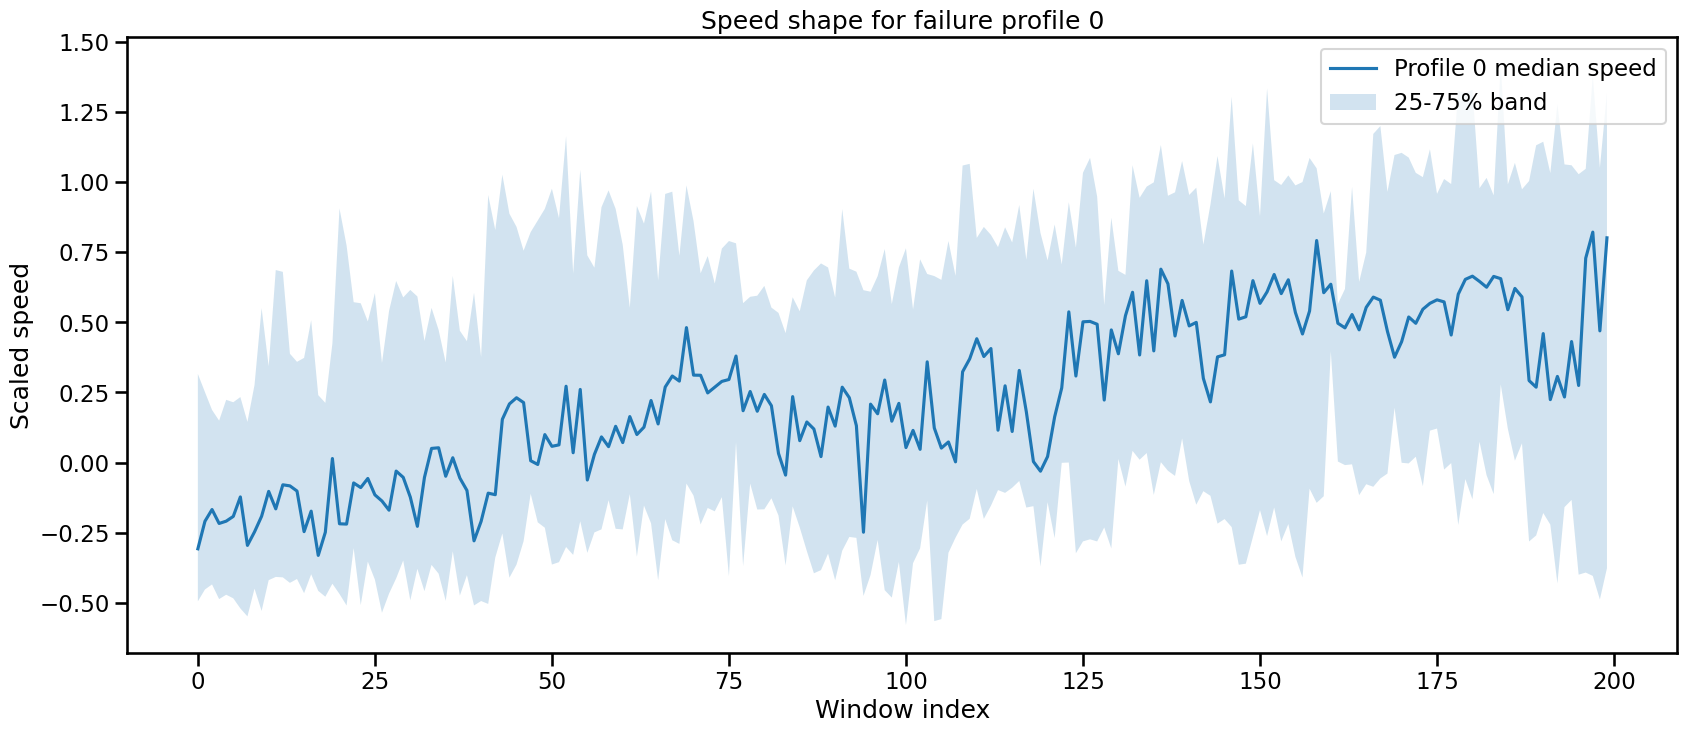

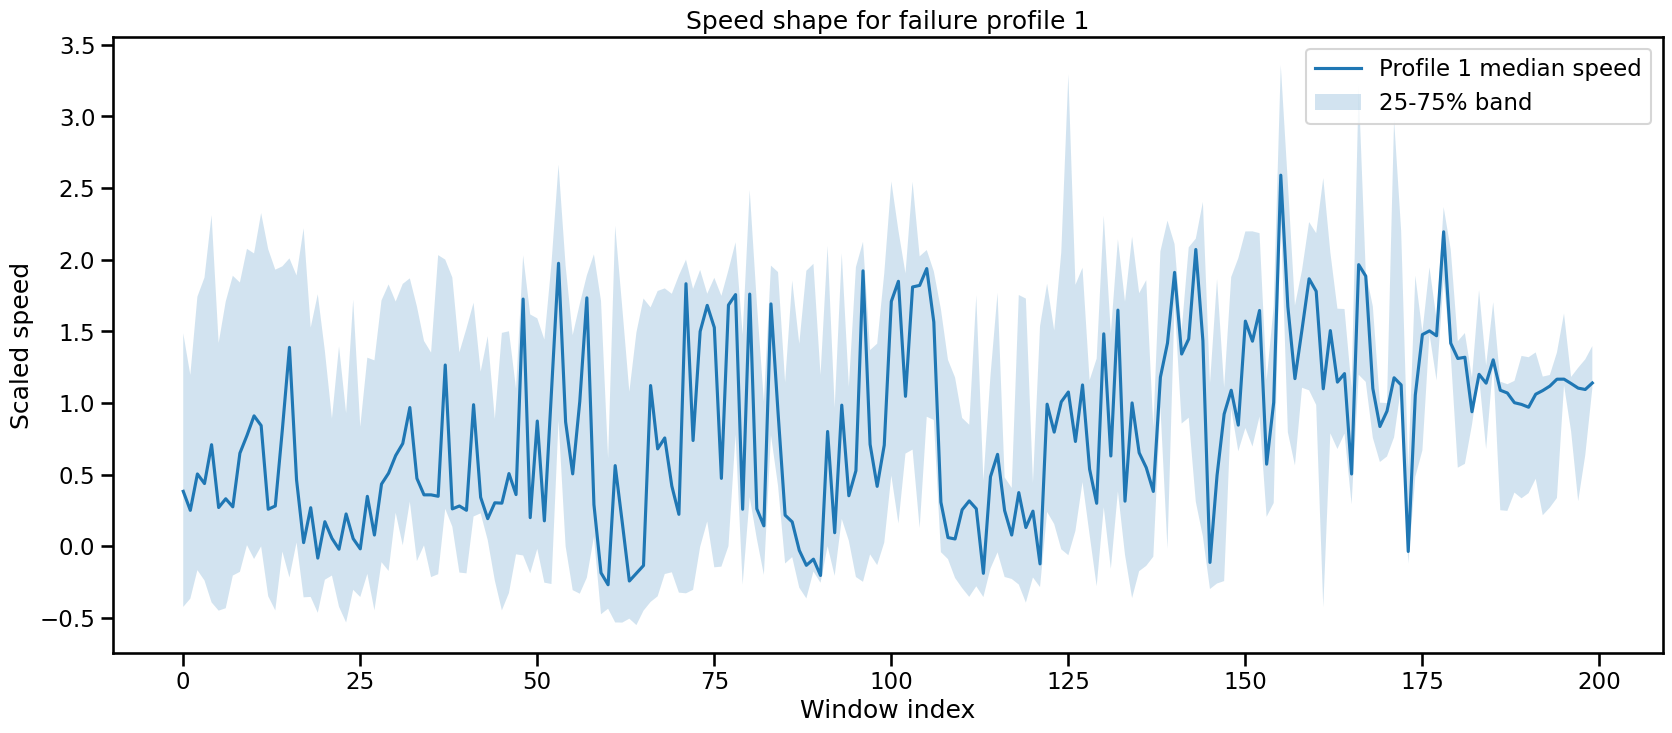

In [16]:
# Visuals per failure profile
if df_train["failure_profile"].notna().any():
    fig, ax = plt.subplots(figsize=(16, 12))
    sns.scatterplot(data=df_train[df_train["failure_profile"].notna()],
                    x="mean_speed", y="std_speed", hue="failure_profile", ax=ax)
    ax.set_title("Failure profiles on 'train' windows")
    plt.show()

    def plot_profile_speed(profile_id, max_samples=50):
        idx = df_train.index[df_train["failure_profile"] == profile_id]
        if len(idx) == 0:
            return
        rng = np.random.default_rng(SEED)
        take = idx if len(idx) <= max_samples else rng.choice(idx, size=max_samples, replace=False)
        seqs = seq_array[take, :, 0].copy()
        masks = mask_array[take]
        seqs[masks] = np.nan
        median = np.nanmedian(seqs, axis=0)
        p25 = np.nanpercentile(seqs, 25, axis=0)
        p75 = np.nanpercentile(seqs, 75, axis=0)
        fig, ax = plt.subplots(figsize=(20, 8))
        ax.plot(median, label=f"Profile {profile_id} median speed")
        ax.fill_between(np.arange(WINDOW_SIZE), p25, p75, alpha=0.2, label="25-75% band")
        ax.set_xlabel("Window index")
        ax.set_ylabel("Scaled speed")
        ax.set_title(f"Speed shape for failure profile {profile_id}")
        ax.legend()
        plt.show()

    plot_profile_speed(0)
    plot_profile_speed(1)


Run the cells to compute the two failure profiles. The tables show which predicted labels dominate each profile and the characteristic speed statistics; the plots help spot whether failures come from low-speed segments (likely bus/walk leakage) or high-speed spikes that look like car/metro.